# Sweep results per $n$, curves by $\eta$

Loads the `(M, v_{\text{pop}})` samples persisted by `scripts/build_eta_pool.py`
(under `src/cache/eta_pool/<param_key>/eta{TT}/sample_NNNN/`), runs a uniform
bootstrap p-sweep on each, and plots `partition_agreement_M` vs $p$ — one
subplot per $n$, one curve per imbalance bin $\eta \in \{1, 5, 10, 15\}$.

Within an $\eta$ bin we average across the saved samples (mean ± std shading).
Sampling is **uniform** only; the metric is `partition_agreement_M` only.

## Pool status — samples cached per $(n, \eta)$

Quick read-only check of `src/cache/eta_pool/` for the param tuple this
notebook uses. Re-run this cell after `build_eta_pool*.py` finishes to see
fresh counts without running the full sweep below.

In [17]:
import sys
from pathlib import Path

_ROOT = Path.cwd()
while _ROOT.parent != _ROOT and not (_ROOT / "setup.py").exists():
    _ROOT = _ROOT.parent
_PROJECT_ROOT = _ROOT / "sub_sampled_fielder_vec"
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

from src.utils.eta_pool_cache import (
    param_key as _param_key,
    list_completed_samples as _list_completed_samples,
    pool_root as _pool_root,
)

# Match Cell 1's param tuple — keep in sync if you change those.
_STATUS_MU         = 0.1
_STATUS_POP_SIZE   = 1.0
_STATUS_SEQ_LEN    = 10_000
_STATUS_TREE_MODEL = "kingman"
_STATUS_SEQ_MODEL  = "JC69"
_STATUS_ETA_TARGETS = [1, 5, 10, 15]
_STATUS_CACHE_ROOT = _PROJECT_ROOT / "src" / "cache"

_key_suffix = _param_key(
    n=0, seq_len=_STATUS_SEQ_LEN, mu=_STATUS_MU,
    tree_model=_STATUS_TREE_MODEL, pop_size=_STATUS_POP_SIZE,
    seq_model=_STATUS_SEQ_MODEL,
).split("_", 1)[1]

_root = _pool_root(_STATUS_CACHE_ROOT)
_rows = []
if _root.exists():
    for _d in sorted(_root.iterdir()):
        if not _d.is_dir() or not _d.name.endswith(_key_suffix):
            continue
        try:
            _n = int(_d.name.split("_", 1)[0][1:])
        except ValueError:
            continue
        _counts = [len(_list_completed_samples(_STATUS_CACHE_ROOT, _d.name, _e))
                   for _e in _STATUS_ETA_TARGETS]
        if any(_counts):
            _rows.append((_n, _counts))

_rows.sort(key=lambda r: r[0])
print(f"pool_root: {_root}")
print(f"params: L={_STATUS_SEQ_LEN}, mu={_STATUS_MU}, "
      f"tree={_STATUS_TREE_MODEL}, pop_size={_STATUS_POP_SIZE}, seq={_STATUS_SEQ_MODEL}")
print()
print(f"  {'n':>6}  " + "  ".join(f"eta={e:>2}" for e in _STATUS_ETA_TARGETS))
for _n, _cs in _rows:
    print(f"  {_n:>6}  " + "  ".join(f"{c:>6d}" for c in _cs))
if not _rows:
    print("  (no pool keys match these params)")


pool_root: /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/cache/pool_sample
params: L=10000, mu=0.1, tree=kingman, pop_size=1.0, seq=JC69

       n  eta= 1  eta= 5  eta=10  eta=15
     500      20      20      20      20
    1000      10      10      10      10
    2000      10      10      10      10
    4000      20      20      20      11
    8000       1       1       1       1


## Cell 1 — Configuration

In [18]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT.parent != ROOT and not (ROOT / "setup.py").exists():
    ROOT = ROOT.parent
PROJECT_ROOT = ROOT / "sub_sampled_fielder_vec"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.eta_pool_cache import (
    param_key, bin_name, list_completed_samples, load_pool_entry, pool_root,
)
from src.runners.p_sweep_inner import bootstrap_p_sweep_simple
from src.utils.sweep_cache import compute_or_load_sweep

CACHE_ROOT = PROJECT_ROOT / "src" / "cache"

# Pool key parameters (must match build_eta_pool.py defaults).
MU         = 0.1
POP_SIZE   = 1.0
SEQ_LEN    = 10_000
TREE_MODEL = "kingman"
SEQ_MODEL  = "JC69"
ETA_TARGETS = [1, 5, 10, 15]

# Sweep parameters. Trim BOOTSTRAP_REPS / P_VALUES if you add bigger n.
P_VALUES                    = np.geomspace(1e-3, 1.0, 25).tolist()
BOOTSTRAP_REPS              = 10
SEED                        = 0
NUM_GAPS                    = 10
MIN_SPLIT                   = 1
MAX_SAMPLES_PER_BIN         = 10  # cap per-(n, eta) work; bins may have 20+ saved samples
EARLY_STOP_CONSECUTIVE_100  = 2  # stop sweep once this many consecutive p's hit 100%
# 'sign' matches the eta-bin definition (n1, n2 from sign of v_pop) and avoids
# partition_taxa picking degenerate (1, n-1) outlier splits.
PARTITION_METHOD            = "sign"
USE_SWEEP_CACHE             = True  # reload prior bootstrap_p_sweep_simple outputs from disk

print(f"pool_root: {pool_root(CACHE_ROOT)}")
print(f"p_values ({len(P_VALUES)}): {[f'{p:.3g}' for p in P_VALUES]}")
print(f"max_samples_per_bin: {MAX_SAMPLES_PER_BIN}")
print(f"early_stop_consecutive_100: {EARLY_STOP_CONSECUTIVE_100}")
print(f"partition_method: {PARTITION_METHOD}")
print(f"use_sweep_cache: {USE_SWEEP_CACHE}")

pool_root: /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/cache/pool_sample
p_values (25): ['0.001', '0.00133', '0.00178', '0.00237', '0.00316', '0.00422', '0.00562', '0.0075', '0.01', '0.0133', '0.0178', '0.0237', '0.0316', '0.0422', '0.0562', '0.075', '0.1', '0.133', '0.178', '0.237', '0.316', '0.422', '0.562', '0.75', '1']
max_samples_per_bin: 10
early_stop_consecutive_100: 2
partition_method: sign
use_sweep_cache: True


## Cell 2 — Discover available $n$ and saved samples

Walk `src/cache/eta_pool/`, parse the `n` from each `param_key` matching the
fixed `(L, μ, tree_model, pop_size, seq_model)` tuple, and report the sample
count per $\eta$ bin.

In [19]:
# Build the param_key suffix that all matching n's share, and look for keys
# that start with 'n{N}' and end with the same suffix.
key_suffix = param_key(
    n=0, seq_len=SEQ_LEN, mu=MU, tree_model=TREE_MODEL,
    pop_size=POP_SIZE, seq_model=SEQ_MODEL,
).split("_", 1)[1]

ns = []
samples_by_n_eta = {}  # (n, eta_target) -> list[int] of completed sample idxs
for d in sorted(pool_root(CACHE_ROOT).iterdir()) if pool_root(CACHE_ROOT).exists() else []:
    if not d.is_dir() or not d.name.endswith(key_suffix):
        continue
    head = d.name.split("_", 1)[0]  # e.g. 'n0500'
    try:
        n = int(head[1:])
    except ValueError:
        continue
    key = d.name
    have_any = False
    for eta in ETA_TARGETS:
        idxs = list_completed_samples(CACHE_ROOT, key, eta)
        samples_by_n_eta[(n, eta)] = idxs
        have_any = have_any or bool(idxs)
    if have_any:
        ns.append(n)

ns = sorted(set(ns))
print(f"Found n values: {ns}")
print(f"\nSamples per (n, eta):")
print(f"  {'n':>6}  " + "  ".join(f"eta={e:>2}" for e in ETA_TARGETS))
for n in ns:
    counts = [len(samples_by_n_eta.get((n, e), [])) for e in ETA_TARGETS]
    print(f"  {n:>6}  " + "  ".join(f"{c:>6d}" for c in counts))

Found n values: [500, 1000, 2000, 4000, 8000]

Samples per (n, eta):
       n  eta= 1  eta= 5  eta=10  eta=15
     500      20      20      20      20
    1000      10      10      10      10
    2000      10      10      10      10
    4000      20      20      20      11
    8000       1       1       1       1


## Cell 3 — Run bootstrap p-sweeps

For each (n, η, sample), load the cached `(M, v_pop)` and call
`bootstrap_p_sweep_simple` (uniform sampling, partition_agreement_M).
Per-sample results are stored in `results[(n, eta)]` as a list of
agreement-curve arrays of length `len(P_VALUES)`.

In [ ]:
results = {}  # (n, eta) -> np.ndarray of shape (n_samples, len(P_VALUES))

for n in ns:
    key = param_key(
        n=n, seq_len=SEQ_LEN, mu=MU, tree_model=TREE_MODEL,
        pop_size=POP_SIZE, seq_model=SEQ_MODEL,
    )
    for eta in ETA_TARGETS:
        idxs = samples_by_n_eta.get((n, eta), [])[:MAX_SAMPLES_PER_BIN]
        if not idxs:
            results[(n, eta)] = np.empty((0, len(P_VALUES)))
            continue
        rows = []
        for idx in idxs:
            def _loader(_key=key, _eta=eta, _idx=idx):
                entry = load_pool_entry(CACHE_ROOT, _key, _eta, _idx)
                if entry is None:
                    return None
                M, v_pop, *_ = entry
                return M, v_pop

            outcome = compute_or_load_sweep(
                cache_root=CACHE_ROOT, param_key=key, eta_target=eta, idx=idx,
                M_loader=_loader,
                p_values=P_VALUES,
                bootstrap_reps=BOOTSTRAP_REPS,
                seed=SEED,
                num_gaps=NUM_GAPS,
                min_split=MIN_SPLIT,
                early_stop_consecutive_100=EARLY_STOP_CONSECUTIVE_100,
                partition_method=PARTITION_METHOD,
                use_cache=USE_SWEEP_CACHE,
            )
            if outcome is None:
                continue
            out, was_cached = outcome
            rows.append(out["partition_agreement_M"])
            tag = "cached" if was_cached else "computed"
            print(f"  n={n:>4}  eta={eta:>2}  sample={idx:>3}  "
                  f"split_ref={tuple(out['partition_split_ref'])}  "
                  f"agr@p_min={rows[-1][0]:5.1f}  agr@p_max={rows[-1][-1]:5.1f}  "
                  f"({tag})")
        results[(n, eta)] = np.asarray(rows) if rows else np.empty((0, len(P_VALUES)))

for (n, eta), arr in sorted(results.items()):
    print(f"  results[(n={n}, eta={eta})].shape = {arr.shape}")

  n= 500  eta= 1  sample=  1  split_ref=(203, 297)  agr@p_min= 56.6  agr@p_max=100.0  (cached)
  n= 500  eta= 1  sample=  2  split_ref=(187, 313)  agr@p_min= 52.4  agr@p_max=100.0  (cached)
  n= 500  eta= 1  sample=  3  split_ref=(207, 293)  agr@p_min= 52.0  agr@p_max=100.0  (cached)
  n= 500  eta= 1  sample=  4  split_ref=(211, 289)  agr@p_min= 53.8  agr@p_max=100.0  (cached)
  n= 500  eta= 1  sample=  5  split_ref=(174, 326)  agr@p_min= 57.4  agr@p_max=100.0  (cached)
  n= 500  eta= 1  sample=  6  split_ref=(241, 259)  agr@p_min= 55.8  agr@p_max=100.0  (cached)
  n= 500  eta= 1  sample=  7  split_ref=(226, 274)  agr@p_min= 54.0  agr@p_max=100.0  (cached)
  n= 500  eta= 1  sample=  8  split_ref=(238, 262)  agr@p_min= 53.4  agr@p_max=100.0  (cached)
  n= 500  eta= 1  sample=  9  split_ref=(189, 311)  agr@p_min= 54.4  agr@p_max=100.0  (cached)
  n= 500  eta= 1  sample= 10  split_ref=(168, 332)  agr@p_min= 52.2  agr@p_max=100.0  (cached)
  n= 500  eta= 5  sample=  1  split_ref=(92, 408) 

## Cell 4 — Plot: one subplot per $n$, curves by $\eta$

Within each $\eta$ bin, the solid line is the mean across saved samples and
the shaded band is ±1 std. Bins with zero samples are skipped silently.

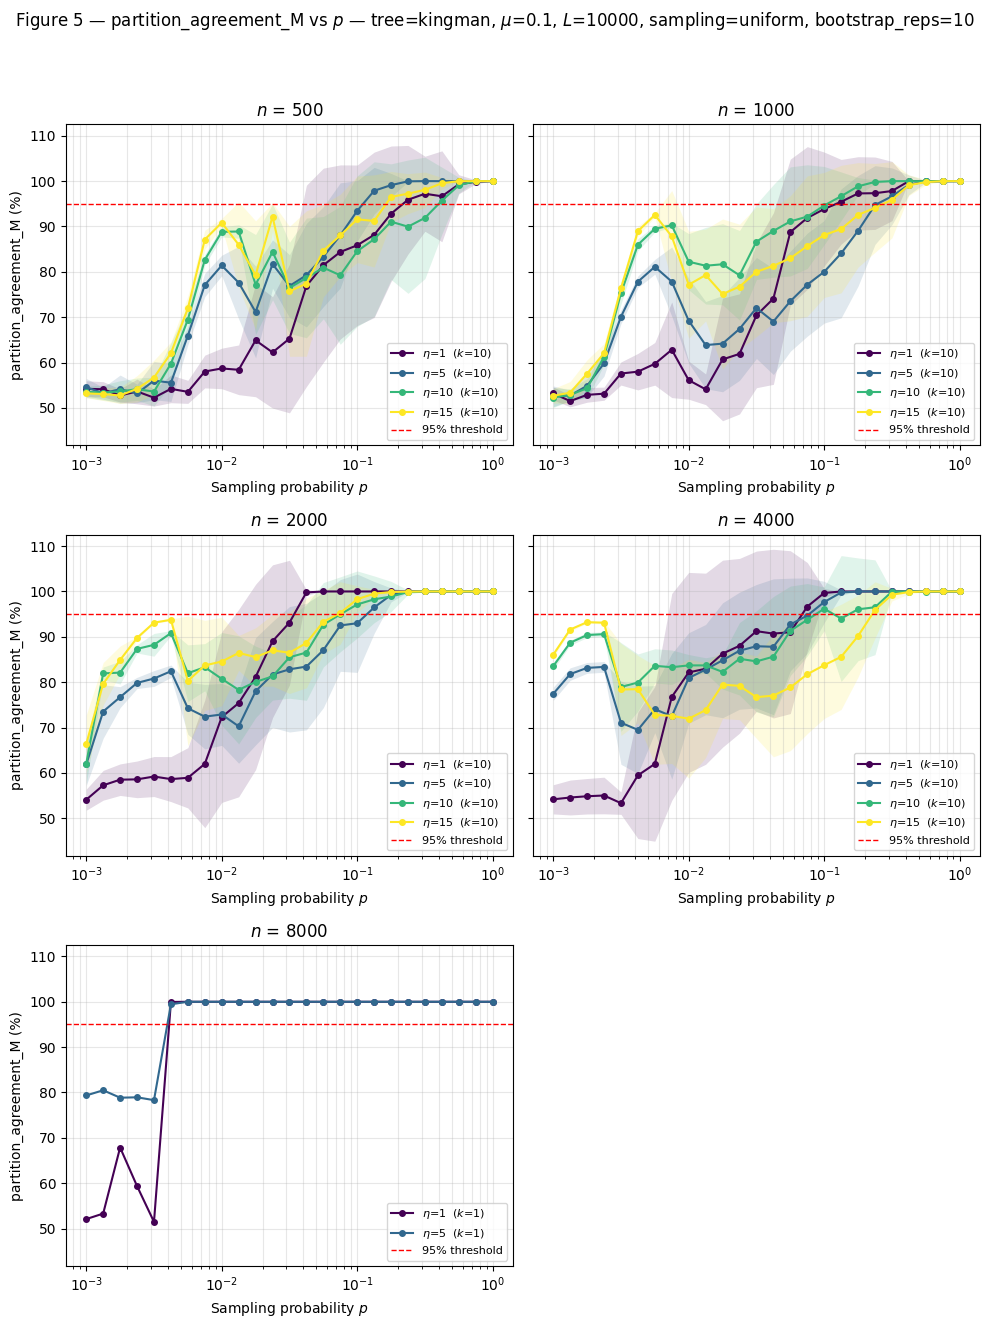

In [ ]:
if not ns:
    print("No matching pool keys found — nothing to plot.")
else:
    cmap = plt.get_cmap("viridis")
    eta_to_color = {
        e: cmap(i / max(1, len(ETA_TARGETS) - 1))
        for i, e in enumerate(ETA_TARGETS)
    }

    n_ns = len(ns)
    ncols = 2
    nrows = (n_ns + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(5 * ncols, 4.5 * nrows),
        sharey=True, squeeze=False,
    )
    axes_flat = axes.flatten()
    fig.suptitle(
        fr"Figure 5 — partition_agreement_M vs $p$ — "
        fr"tree={TREE_MODEL}, $\mu$={MU}, $L$={SEQ_LEN}, sampling=uniform, "
        fr"bootstrap_reps={BOOTSTRAP_REPS}"
    )

    for ax, n in zip(axes_flat, ns):
        for eta in ETA_TARGETS:
            arr = results.get((n, eta))
            if arr is None or arr.shape[0] == 0:
                continue
            mean = arr.mean(axis=0)
            std = arr.std(axis=0) if arr.shape[0] > 1 else np.zeros_like(mean)
            color = eta_to_color[eta]
            ax.plot(
                P_VALUES, mean, "-o", ms=4, lw=1.5, color=color,
                label=fr"$\eta$={eta}  ($k$={arr.shape[0]})",
            )
            if arr.shape[0] > 1:
                ax.fill_between(P_VALUES, mean - std, mean + std,
                                color=color, alpha=0.15, linewidth=0)

        ax.axhline(95.0, color="red", ls="--", lw=1, label="95% threshold")
        ax.set_xscale("log")
        ax.set_xlabel(r"Sampling probability $p$")
        ax.set_title(fr"$n$ = {n}")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend(loc="lower right", fontsize=8)

    for ax in axes_flat[n_ns:]:
        ax.set_visible(False)

    for row in axes:
        row[0].set_ylabel("partition_agreement_M (%)")
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()

## Cell 5 — Plot 2 sweep: one sample per $(n, \eta)$, closest to bin target

For each $(n, \eta_{\text{target}})$, pick the cached sample whose measured
$\eta$ is closest to the target, run a single bootstrap p-sweep, and store
the result. No averaging across samples — one curve per $(n, \eta)$. This
mirrors the recovery-curves panel of `kingman_threshold_vs_theory.ipynb`.

In [ ]:
import json
from src.utils.eta_pool_cache import sample_dir

single_results = {}  # (n, eta_target) -> {"agreement", "eta_actual", "idx"}

for n in ns:
    key = param_key(
        n=n, seq_len=SEQ_LEN, mu=MU, tree_model=TREE_MODEL,
        pop_size=POP_SIZE, seq_model=SEQ_MODEL,
    )
    for eta_target in ETA_TARGETS:
        idxs = samples_by_n_eta.get((n, eta_target), [])
        if not idxs:
            continue

        # Read just metadata for each candidate to find the closest measured eta.
        candidates = []
        for idx in idxs:
            meta_path = sample_dir(CACHE_ROOT, key, eta_target, idx) / "metadata.json"
            if not meta_path.exists():
                continue
            with open(meta_path, "r") as f:
                meta = json.load(f)
            candidates.append((idx, float(meta["eta"])))
        if not candidates:
            continue

        idx_star, eta_actual = min(
            candidates, key=lambda t: abs(t[1] - float(eta_target))
        )

        def _loader(_key=key, _eta=eta_target, _idx=idx_star):
            entry = load_pool_entry(CACHE_ROOT, _key, _eta, _idx)
            if entry is None:
                return None
            M, v_pop, *_ = entry
            return M, v_pop

        outcome = compute_or_load_sweep(
            cache_root=CACHE_ROOT, param_key=key, eta_target=eta_target, idx=idx_star,
            M_loader=_loader,
            p_values=P_VALUES,
            bootstrap_reps=BOOTSTRAP_REPS,
            seed=SEED,
            num_gaps=NUM_GAPS,
            min_split=MIN_SPLIT,
            early_stop_consecutive_100=EARLY_STOP_CONSECUTIVE_100,
            partition_method=PARTITION_METHOD,
            use_cache=USE_SWEEP_CACHE,
        )
        if outcome is None:
            continue
        out, was_cached = outcome
        agr = np.asarray(out["partition_agreement_M"], dtype=float)
        single_results[(n, eta_target)] = {
            "agreement": agr,
            "eta_actual": eta_actual,
            "idx": idx_star,
        }
        tag = "cached" if was_cached else "computed"
        print(
            f"  n={n:>4}  eta_target={eta_target:>2}  idx={idx_star:>3}  "
            f"eta_actual={eta_actual:5.2f}  "
            f"agr@p_min={agr[0]:5.1f}  agr@p_max={agr[-1]:5.1f}  ({tag})"
        )

print(f"\nselected {len(single_results)} (n, eta_target) curves")

  n= 500  eta_target= 1  idx= 15  eta_actual= 1.03  agr@p_min= 53.0  agr@p_max=100.0  (computed)
  n= 500  eta_target= 5  idx=  7  eta_actual= 5.02  agr@p_min= 51.2  agr@p_max=100.0  (cached)
  n= 500  eta_target=10  idx=  2  eta_actual=10.11  agr@p_min= 52.6  agr@p_max=100.0  (cached)
  n= 500  eta_target=15  idx=  1  eta_actual=15.13  agr@p_min= 53.4  agr@p_max=100.0  (cached)
  n=1000  eta_target= 1  idx=  3  eta_actual= 1.00  agr@p_min= 54.4  agr@p_max=100.0  (cached)
  n=1000  eta_target= 5  idx=  4  eta_actual= 4.92  agr@p_min= 52.6  agr@p_max=100.0  (cached)
  n=1000  eta_target=10  idx=  4  eta_actual= 9.87  agr@p_min= 53.9  agr@p_max=100.0  (cached)
  n=1000  eta_target=15  idx=  6  eta_actual=14.87  agr@p_min= 53.4  agr@p_max=100.0  (cached)
  n=2000  eta_target= 1  idx=  5  eta_actual= 1.13  agr@p_min= 52.5  agr@p_max=100.0  (cached)
  n=2000  eta_target= 5  idx=  1  eta_actual= 5.01  agr@p_min= 57.2  agr@p_max=100.0  (cached)
  n=2000  eta_target=10  idx=  7  eta_actual=10.

## Cell 6 — Plot 2: one subplot per $\eta$, curves by $n$

Mirrors the recovery-curves panel of `kingman_threshold_vs_theory.ipynb`:
each subplot fixes a $\eta$ bin, and each curve is a different $n$. Only one
sample per curve (closest measured $\eta$ to the bin target).

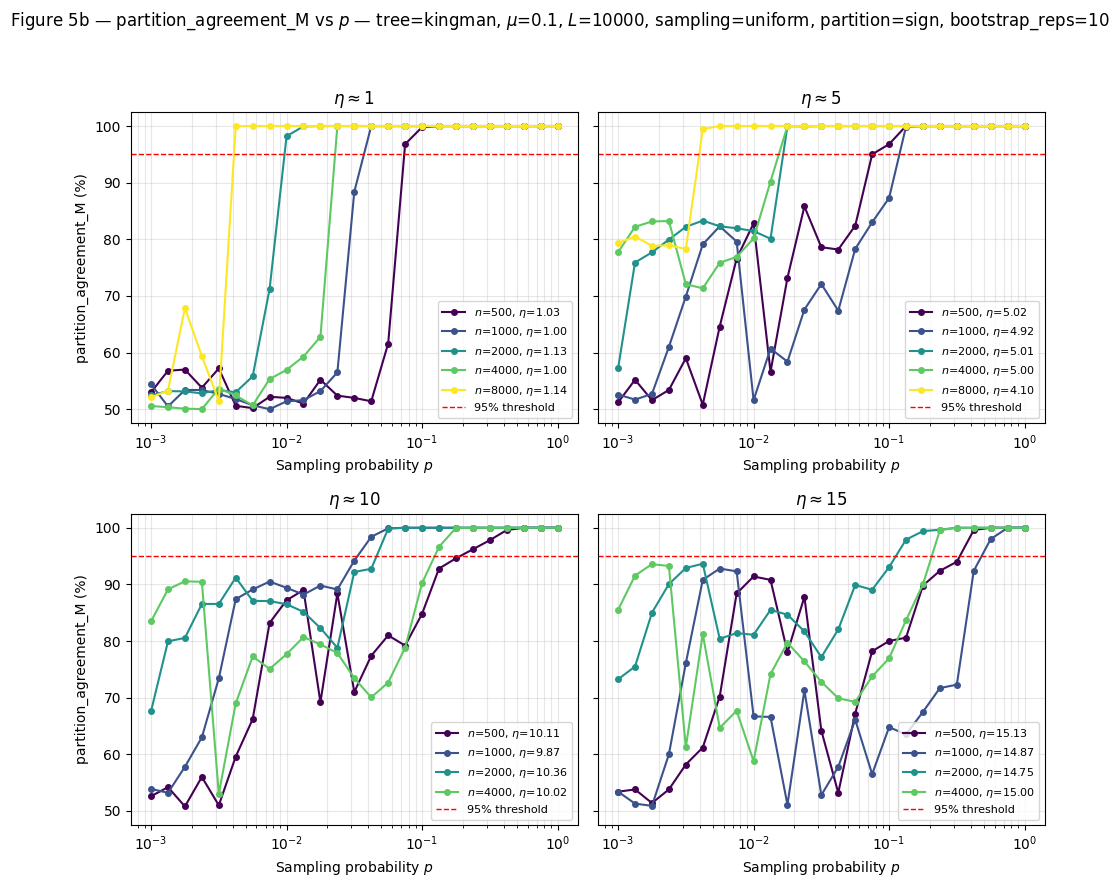

In [ ]:
if not single_results:
    print("No single-sample sweeps available — nothing to plot.")
else:
    cmap = plt.get_cmap("viridis")
    n_to_color = {
        n: cmap(i / max(1, len(ns) - 1))
        for i, n in enumerate(ns)
    }

    n_etas = len(ETA_TARGETS)
    ncols = 2
    nrows = (n_etas + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(5 * ncols, 4.5 * nrows),
        sharey=True, squeeze=False,
    )
    axes_flat = axes.flatten()
    fig.suptitle(
        fr"Figure 5b — partition_agreement_M vs $p$ — "
        fr"tree={TREE_MODEL}, $\mu$={MU}, $L$={SEQ_LEN}, sampling=uniform, "
        fr"partition={PARTITION_METHOD}, bootstrap_reps={BOOTSTRAP_REPS}"
    )

    for ax, eta_target in zip(axes_flat, ETA_TARGETS):
        for n in ns:
            entry = single_results.get((n, eta_target))
            if entry is None:
                continue
            ax.plot(
                P_VALUES, entry["agreement"], "-o", ms=4, lw=1.5,
                color=n_to_color[n],
                label=fr"$n$={n}, $\eta$={entry['eta_actual']:.2f}",
            )

        ax.axhline(95.0, color="red", ls="--", lw=1, label="95% threshold")
        ax.set_xscale("log")
        ax.set_xlabel(r"Sampling probability $p$")
        ax.set_title(fr"$\eta \approx {eta_target}$")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend(loc="lower right", fontsize=8)

    for ax in axes_flat[n_etas:]:
        ax.set_visible(False)

    for row in axes:
        row[0].set_ylabel("partition_agreement_M (%)")
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()

## Cell 7 — Plot 3: critical $p^*$ vs $n$, one curve per $\eta$

For each $(n, \eta)$, take the mean `partition_agreement_M` across saved samples
(from Cell 3's `results`), and define $p^*(n, \eta)$ as the smallest $p$ in the grid
at which the mean agreement reaches the 95% recovery threshold. Plot $p^*$ vs $n$
on log–log axes with one curve per $\eta$ — the figure-3 right-panel summary, but
collapsed into a single plot.

In [ ]:
from analysis.comparison.phase_transition_utils import find_discrete_threshold

RECOVERY_THRESHOLD_PCT = 95.0  # results[*] is in percent (0..100)

# Semantic palette: gray = balanced reference (eta=1), blue→orange→red = increasing imbalance.
ETA_COLORS = {
    1:  "#4b5563",
    5:  "#1d4ed8",
    10: "#ea580c",
    15: "#b91c1c",
}

p_arr = np.asarray(P_VALUES, dtype=float)
p_star_by_eta = {}  # eta -> list of (n, p_star) with finite p_star

for eta in ETA_TARGETS:
    rows = []
    for n in ns:
        arr = results.get((n, eta))
        if arr is None or arr.shape[0] == 0:
            continue
        mean_curve = arr.mean(axis=0)
        p_star = find_discrete_threshold(p_arr, mean_curve, threshold=RECOVERY_THRESHOLD_PCT)
        if p_star is None or not np.isfinite(p_star):
            continue
        rows.append((n, float(p_star)))
    p_star_by_eta[eta] = rows
    print(f"  eta={eta:>2}: " + ", ".join(f"n={n}→p*={p:.4g}" for n, p in rows))

fig, ax = plt.subplots(figsize=(7, 7))
for eta in ETA_TARGETS:
    rows = p_star_by_eta.get(eta, [])
    if not rows:
        continue
    xs = np.array([r[0] for r in rows], dtype=float)
    ys = np.array([r[1] for r in rows], dtype=float)
    ax.plot(
        xs, ys, "-o", ms=6, lw=2,
        color=ETA_COLORS.get(eta, "#000000"),
        label=fr"$\eta$ = {eta}",
    )

# Per-eta log(n)/n reference, least-squares-fit to each eta's own p* points.
n_grid = np.array(sorted(ns), dtype=float)
g_grid = np.log(n_grid) / n_grid
for _i, eta in enumerate(ETA_TARGETS):
    _rows = p_star_by_eta.get(eta, [])
    if not _rows:
        continue
    _xs = np.array([r[0] for r in _rows], dtype=float)
    _ys = np.array([r[1] for r in _rows], dtype=float)
    _g = np.log(_xs) / _xs
    _C = float(np.dot(_g, _ys) / np.dot(_g, _g))  # fit p* = C * log(n)/n
    ax.plot(n_grid, _C * g_grid, "--", lw=1.5, alpha=0.4, zorder=1,
            color=ETA_COLORS.get(eta, "#000000"),
            label=(r"$\log n/n$ fit (per $\eta$)" if _i == 0 else None))

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Number of taxa $n$")
ax.set_ylabel(r"Critical sampling probability $p^*$  (smallest $p$ with mean partition_agreement_M $\geq 95\%$)")
ax.set_title(
    fr"$p^*(n)$ for kingman tree, $\mu$={MU}, $L$={SEQ_LEN}, uniform sampling, "
    fr"bootstrap_reps={BOOTSTRAP_REPS}"
)
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower left", fontsize=10)
fig.tight_layout()
plt.show()

## Cell 8 — ARI overlay

Same sweeps as above, but reading `partition_ari_M` from the cached results.
ARI ∈ [-1, 1] is invariant under bipartition label flips (no `max(direct,
flipped)` needed) and discounts the trivial-majority bias that inflates
`partition_agreement_M` on unbalanced (η ≫ 1) splits.

This cell re-calls `compute_or_load_sweep` (v2 schema), which now returns
`partition_ari_M` alongside `partition_agreement_M`. With the v2 cache
populated, every call should be a cache hit.

In [ ]:
results_ari = {}  # (n, eta) -> np.ndarray of shape (n_samples, len(P_VALUES))

for n in ns:
    key = param_key(
        n=n, seq_len=SEQ_LEN, mu=MU, tree_model=TREE_MODEL,
        pop_size=POP_SIZE, seq_model=SEQ_MODEL,
    )
    for eta in ETA_TARGETS:
        idxs = samples_by_n_eta.get((n, eta), [])[:MAX_SAMPLES_PER_BIN]
        if not idxs:
            results_ari[(n, eta)] = np.empty((0, len(P_VALUES)))
            continue
        rows = []
        for idx in idxs:
            def _loader(_key=key, _eta=eta, _idx=idx):
                entry = load_pool_entry(CACHE_ROOT, _key, _eta, _idx)
                if entry is None:
                    return None
                M, v_pop, *_ = entry
                return M, v_pop

            outcome = compute_or_load_sweep(
                cache_root=CACHE_ROOT, param_key=key, eta_target=eta, idx=idx,
                M_loader=_loader,
                p_values=P_VALUES,
                bootstrap_reps=BOOTSTRAP_REPS,
                seed=SEED,
                num_gaps=NUM_GAPS,
                min_split=MIN_SPLIT,
                early_stop_consecutive_100=EARLY_STOP_CONSECUTIVE_100,
                partition_method=PARTITION_METHOD,
                use_cache=USE_SWEEP_CACHE,
            )
            if outcome is None:
                continue
            out, _ = outcome
            ari_curve = out.get("partition_ari_M")
            if ari_curve is None:
                continue
            rows.append(ari_curve)
        results_ari[(n, eta)] = np.asarray(rows) if rows else np.empty((0, len(P_VALUES)))

for (n, eta), arr in sorted(results_ari.items()):
    print(f"  results_ari[(n={n}, eta={eta})].shape = {arr.shape}")

  results_ari[(n=500, eta=1)].shape = (10, 25)
  results_ari[(n=500, eta=5)].shape = (10, 25)
  results_ari[(n=500, eta=10)].shape = (10, 25)
  results_ari[(n=500, eta=15)].shape = (10, 25)
  results_ari[(n=1000, eta=1)].shape = (10, 25)
  results_ari[(n=1000, eta=5)].shape = (10, 25)
  results_ari[(n=1000, eta=10)].shape = (10, 25)
  results_ari[(n=1000, eta=15)].shape = (10, 25)
  results_ari[(n=2000, eta=1)].shape = (10, 25)
  results_ari[(n=2000, eta=5)].shape = (10, 25)
  results_ari[(n=2000, eta=10)].shape = (10, 25)
  results_ari[(n=2000, eta=15)].shape = (10, 25)
  results_ari[(n=4000, eta=1)].shape = (10, 25)
  results_ari[(n=4000, eta=5)].shape = (10, 25)
  results_ari[(n=4000, eta=10)].shape = (10, 25)
  results_ari[(n=4000, eta=15)].shape = (10, 25)
  results_ari[(n=8000, eta=1)].shape = (1, 25)
  results_ari[(n=8000, eta=5)].shape = (1, 25)
  results_ari[(n=8000, eta=10)].shape = (0, 25)
  results_ari[(n=8000, eta=15)].shape = (0, 25)


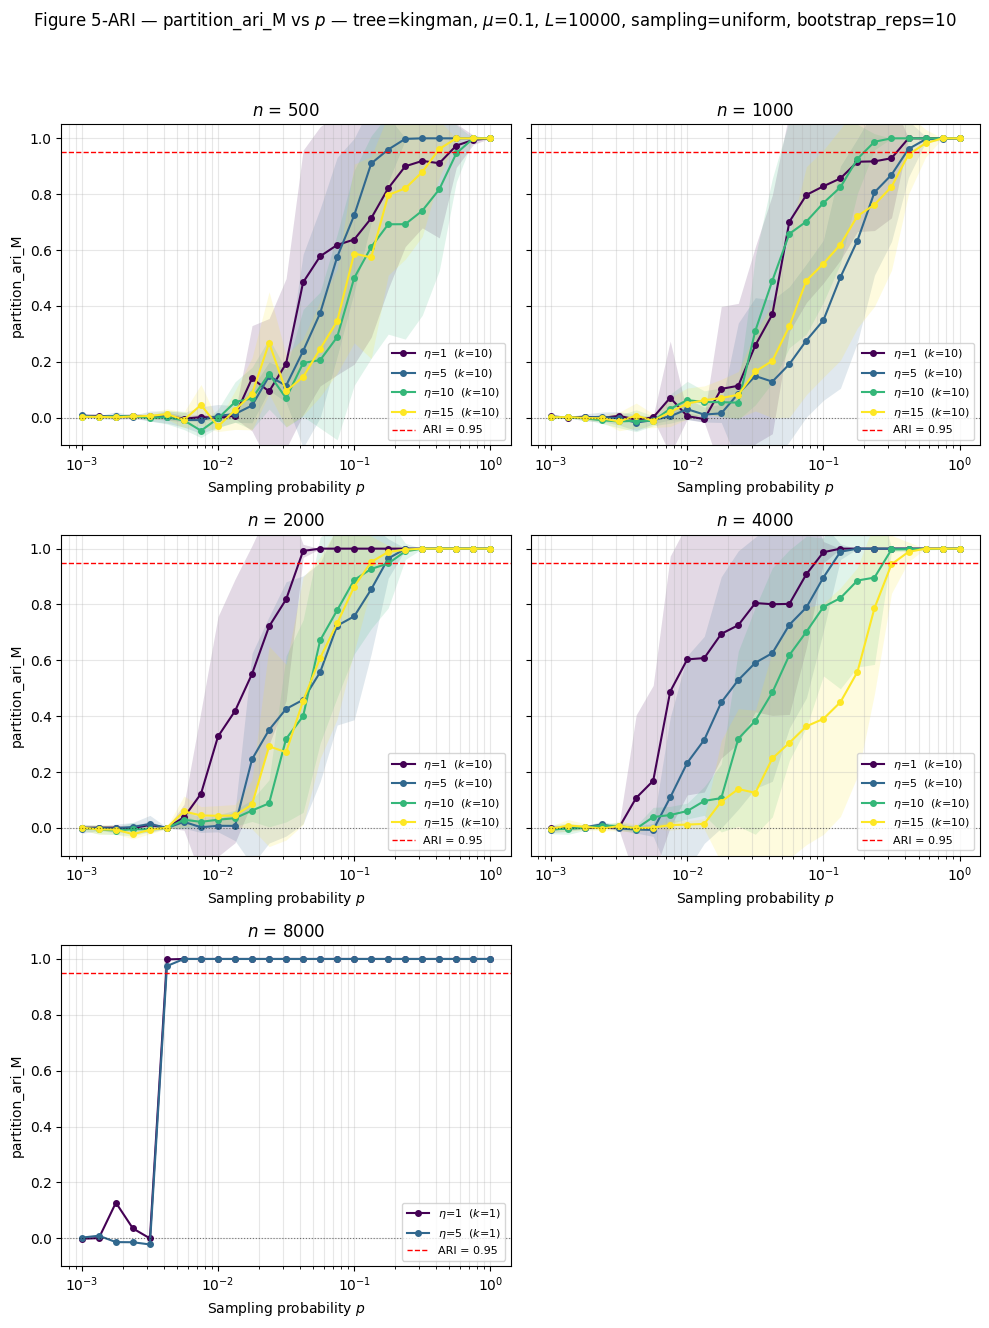

In [ ]:
# Figure 5-ARI — mean partition_ari_M vs p, one subplot per n, curves by eta.
if not ns:
    print("No matching pool keys found — nothing to plot.")
else:
    cmap = plt.get_cmap("viridis")
    eta_to_color = {
        e: cmap(i / max(1, len(ETA_TARGETS) - 1))
        for i, e in enumerate(ETA_TARGETS)
    }

    n_ns = len(ns)
    ncols = 2
    nrows = (n_ns + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(5 * ncols, 4.5 * nrows),
        sharey=True, squeeze=False,
    )
    axes_flat = axes.flatten()
    fig.suptitle(
        fr"Figure 5-ARI — partition_ari_M vs $p$ — "
        fr"tree={TREE_MODEL}, $\mu$={MU}, $L$={SEQ_LEN}, sampling=uniform, "
        fr"bootstrap_reps={BOOTSTRAP_REPS}"
    )

    for ax, n in zip(axes_flat, ns):
        for eta in ETA_TARGETS:
            arr = results_ari.get((n, eta))
            if arr is None or arr.shape[0] == 0:
                continue
            mean = arr.mean(axis=0)
            std = arr.std(axis=0) if arr.shape[0] > 1 else np.zeros_like(mean)
            color = eta_to_color[eta]
            ax.plot(
                P_VALUES, mean, "-o", ms=4, lw=1.5, color=color,
                label=fr"$\eta$={eta}  ($k$={arr.shape[0]})",
            )
            if arr.shape[0] > 1:
                ax.fill_between(P_VALUES, mean - std, mean + std,
                                color=color, alpha=0.15, linewidth=0)

        ax.axhline(0.95, color="red", ls="--", lw=1, label="ARI = 0.95")
        ax.axhline(0.0, color="black", ls=":", lw=0.8, alpha=0.5)
        ax.set_xscale("log")
        ax.set_xlabel(r"Sampling probability $p$")
        ax.set_title(fr"$n$ = {n}")
        ax.set_ylim(-0.1, 1.05)
        ax.grid(True, which="both", alpha=0.3)
        ax.legend(loc="lower right", fontsize=8)

    for ax in axes_flat[n_ns:]:
        ax.set_visible(False)

    for row in axes:
        row[0].set_ylabel("partition_ari_M")
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()

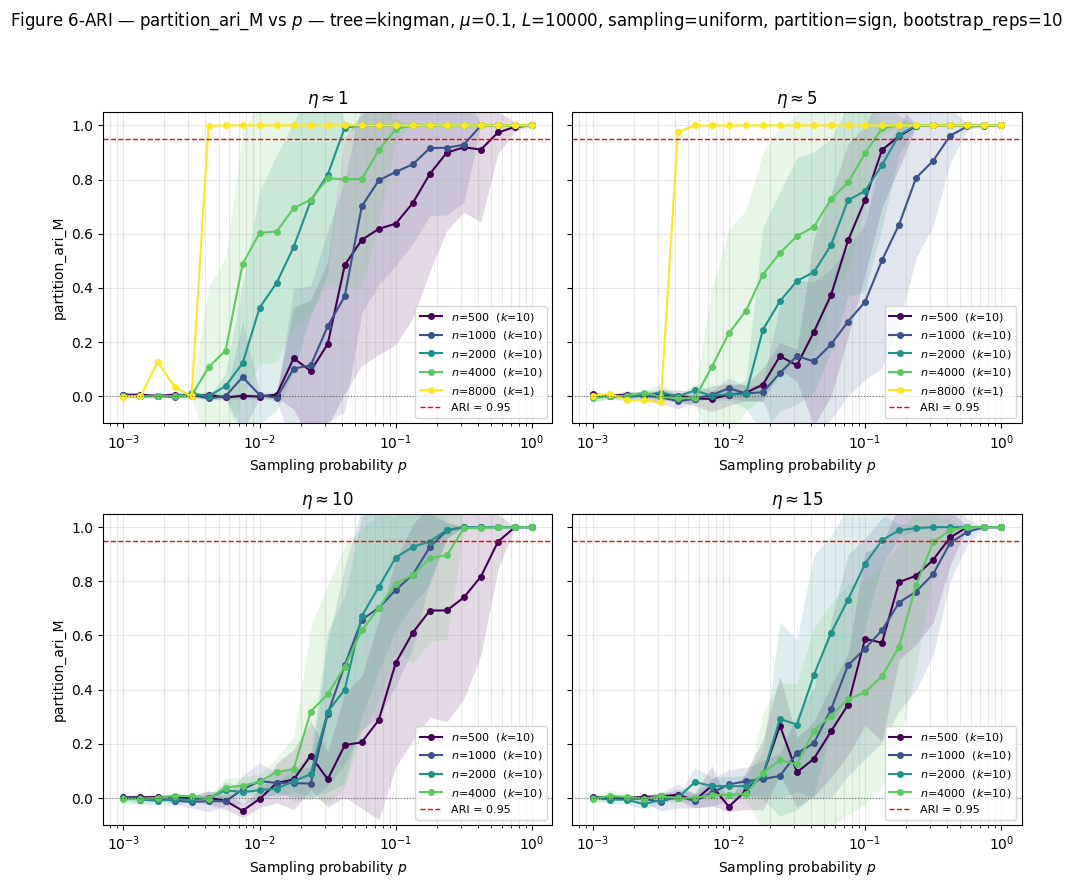

In [ ]:
# Figure 6-ARI — mean partition_ari_M vs p, one subplot per eta, curves by n.
if not ns:
    print("No matching pool keys found — nothing to plot.")
else:
    cmap = plt.get_cmap("viridis")
    n_to_color = {
        n: cmap(i / max(1, len(ns) - 1))
        for i, n in enumerate(ns)
    }

    n_etas = len(ETA_TARGETS)
    ncols = 2
    nrows = (n_etas + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(5 * ncols, 4.5 * nrows),
        sharey=True, squeeze=False,
    )
    axes_flat = axes.flatten()
    fig.suptitle(
        fr"Figure 6-ARI — partition_ari_M vs $p$ — "
        fr"tree={TREE_MODEL}, $\mu$={MU}, $L$={SEQ_LEN}, sampling=uniform, "
        fr"partition={PARTITION_METHOD}, bootstrap_reps={BOOTSTRAP_REPS}"
    )

    for ax, eta in zip(axes_flat, ETA_TARGETS):
        for n in ns:
            arr = results_ari.get((n, eta))
            if arr is None or arr.shape[0] == 0:
                continue
            mean = arr.mean(axis=0)
            std = arr.std(axis=0) if arr.shape[0] > 1 else np.zeros_like(mean)
            color = n_to_color[n]
            ax.plot(
                P_VALUES, mean, "-o", ms=4, lw=1.5, color=color,
                label=fr"$n$={n}  ($k$={arr.shape[0]})",
            )
            if arr.shape[0] > 1:
                ax.fill_between(P_VALUES, mean - std, mean + std,
                                color=color, alpha=0.15, linewidth=0)

        ax.axhline(0.95, color="red", ls="--", lw=1, label="ARI = 0.95")
        ax.axhline(0.0, color="black", ls=":", lw=0.8, alpha=0.5)
        ax.set_xscale("log")
        ax.set_xlabel(r"Sampling probability $p$")
        ax.set_title(fr"$\eta \approx {eta}$")
        ax.set_ylim(-0.1, 1.05)
        ax.grid(True, which="both", alpha=0.3)
        ax.legend(loc="lower right", fontsize=8)

    for ax in axes_flat[n_etas:]:
        ax.set_visible(False)

    for row in axes:
        row[0].set_ylabel("partition_ari_M")
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()

  eta= 1: n=500→p*=0.5623, n=1000→p*=0.4217, n=2000→p*=0.04217, n=4000→p*=0.1, n=8000→p*=0.004217
  eta= 5: n=500→p*=0.1778, n=1000→p*=0.4217, n=2000→p*=0.1778, n=4000→p*=0.1334, n=8000→p*=0.004217
  eta=10: n=500→p*=0.7499, n=1000→p*=0.2371, n=2000→p*=0.2371, n=4000→p*=0.3162, n=8000→p*=0.05623
  eta=15: n=500→p*=0.4217, n=1000→p*=0.5623, n=2000→p*=0.1334, n=4000→p*=0.4217, n=8000→p*=0.05623


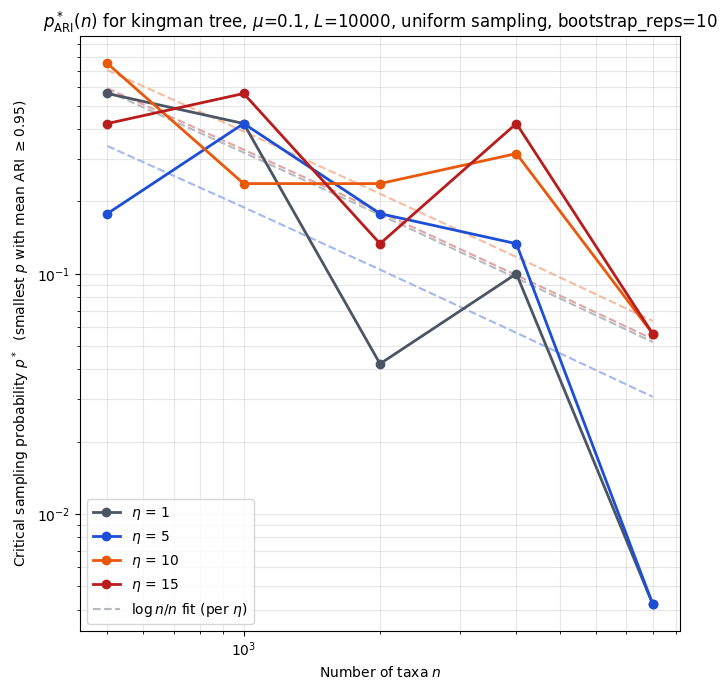

In [33]:
# Figure 7-ARI — critical p* vs n using ARI ≥ 0.95 as the recovery threshold.
RECOVERY_THRESHOLD_ARI = 0.95  # results_ari is ARI in [-1, 1]

p_arr = np.asarray(P_VALUES, dtype=float)
p_star_ari_by_eta = {}

for eta in ETA_TARGETS:
    rows = []
    for n in ns:
        arr = results_ari.get((n, eta))
        if arr is None or arr.shape[0] == 0:
            continue
        mean_curve = arr.mean(axis=0)
        p_star = find_discrete_threshold(p_arr, mean_curve, threshold=RECOVERY_THRESHOLD_ARI)
        if p_star is None or not np.isfinite(p_star):
            continue
        rows.append((n, float(p_star)))
    p_star_ari_by_eta[eta] = rows
    print(f"  eta={eta:>2}: " + ", ".join(f"n={n}→p*={p:.4g}" for n, p in rows))

fig, ax = plt.subplots(figsize=(7, 7))
for eta in ETA_TARGETS:
    rows = p_star_ari_by_eta.get(eta, [])
    if not rows:
        continue
    xs = np.array([r[0] for r in rows], dtype=float)
    ys = np.array([r[1] for r in rows], dtype=float)
    ax.plot(
        xs, ys, "-o", ms=6, lw=2,
        color=ETA_COLORS.get(eta, "#000000"),
        label=fr"$\eta$ = {eta}",
    )

# Per-eta log(n)/n reference, least-squares-fit to each eta's own p* points.
n_grid = np.array(sorted(ns), dtype=float)
g_grid = np.log(n_grid) / n_grid
for _i, eta in enumerate(ETA_TARGETS):
    _rows = p_star_ari_by_eta.get(eta, [])
    if not _rows:
        continue
    _xs = np.array([r[0] for r in _rows], dtype=float)
    _ys = np.array([r[1] for r in _rows], dtype=float)
    _g = np.log(_xs) / _xs
    _C = float(np.dot(_g, _ys) / np.dot(_g, _g))  # fit p* = C * log(n)/n
    ax.plot(n_grid, _C * g_grid, "--", lw=1.5, alpha=0.4, zorder=1,
            color=ETA_COLORS.get(eta, "#000000"),
            label=(r"$\log n/n$ fit (per $\eta$)" if _i == 0 else None))

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Number of taxa $n$")
ax.set_ylabel(r"Critical sampling probability $p^*$  (smallest $p$ with mean ARI $\geq 0.95$)")
ax.set_title(
    fr"$p^*_{{\mathrm{{ARI}}}}(n)$ for kingman tree, $\mu$={MU}, $L$={SEQ_LEN}, uniform sampling, "
    fr"bootstrap_reps={BOOTSTRAP_REPS}"
)
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower left", fontsize=10)
fig.tight_layout()
plt.show()

## Cell 9 — NMI overlay

Same sweeps as above, but reading `partition_nmi_M` from the cached results.
NMI ∈ [0, 1] is label-permutation invariant (like ARI), but unlike ARI it is
*not* corrected for chance — it weights label co-occurrences by mutual
information rather than pair-counts, which makes it more sensitive to the
minority cluster on imbalanced (η ≫ 1) splits and tends to show a sharper
phase transition than ARI.

Cache schema is bumped to **v3** to include `partition_nmi_M`; first run will
re-compute (old v2 entries are ignored).

In [ ]:
results_nmi = {}  # (n, eta) -> np.ndarray of shape (n_samples, len(P_VALUES))

for n in ns:
    key = param_key(
        n=n, seq_len=SEQ_LEN, mu=MU, tree_model=TREE_MODEL,
        pop_size=POP_SIZE, seq_model=SEQ_MODEL,
    )
    for eta in ETA_TARGETS:
        idxs = samples_by_n_eta.get((n, eta), [])[:MAX_SAMPLES_PER_BIN]
        if not idxs:
            results_nmi[(n, eta)] = np.empty((0, len(P_VALUES)))
            continue
        rows = []
        for idx in idxs:
            def _loader(_key=key, _eta=eta, _idx=idx):
                entry = load_pool_entry(CACHE_ROOT, _key, _eta, _idx)
                if entry is None:
                    return None
                M, v_pop, *_ = entry
                return M, v_pop

            outcome = compute_or_load_sweep(
                cache_root=CACHE_ROOT, param_key=key, eta_target=eta, idx=idx,
                M_loader=_loader,
                p_values=P_VALUES,
                bootstrap_reps=BOOTSTRAP_REPS,
                seed=SEED,
                num_gaps=NUM_GAPS,
                min_split=MIN_SPLIT,
                early_stop_consecutive_100=EARLY_STOP_CONSECUTIVE_100,
                partition_method=PARTITION_METHOD,
                use_cache=USE_SWEEP_CACHE,
            )
            if outcome is None:
                continue
            out, _ = outcome
            nmi_curve = out.get("partition_nmi_M")
            if nmi_curve is None:
                continue
            rows.append(nmi_curve)
        results_nmi[(n, eta)] = np.asarray(rows) if rows else np.empty((0, len(P_VALUES)))

for (n, eta), arr in sorted(results_nmi.items()):
    print(f"  results_nmi[(n={n}, eta={eta})].shape = {arr.shape}")

  results_nmi[(n=500, eta=1)].shape = (10, 25)
  results_nmi[(n=500, eta=5)].shape = (10, 25)
  results_nmi[(n=500, eta=10)].shape = (10, 25)
  results_nmi[(n=500, eta=15)].shape = (10, 25)
  results_nmi[(n=1000, eta=1)].shape = (10, 25)
  results_nmi[(n=1000, eta=5)].shape = (10, 25)
  results_nmi[(n=1000, eta=10)].shape = (10, 25)
  results_nmi[(n=1000, eta=15)].shape = (10, 25)
  results_nmi[(n=2000, eta=1)].shape = (10, 25)
  results_nmi[(n=2000, eta=5)].shape = (10, 25)
  results_nmi[(n=2000, eta=10)].shape = (10, 25)
  results_nmi[(n=2000, eta=15)].shape = (10, 25)
  results_nmi[(n=4000, eta=1)].shape = (10, 25)
  results_nmi[(n=4000, eta=5)].shape = (10, 25)
  results_nmi[(n=4000, eta=10)].shape = (10, 25)
  results_nmi[(n=4000, eta=15)].shape = (10, 25)
  results_nmi[(n=8000, eta=1)].shape = (1, 25)
  results_nmi[(n=8000, eta=5)].shape = (1, 25)
  results_nmi[(n=8000, eta=10)].shape = (0, 25)
  results_nmi[(n=8000, eta=15)].shape = (0, 25)


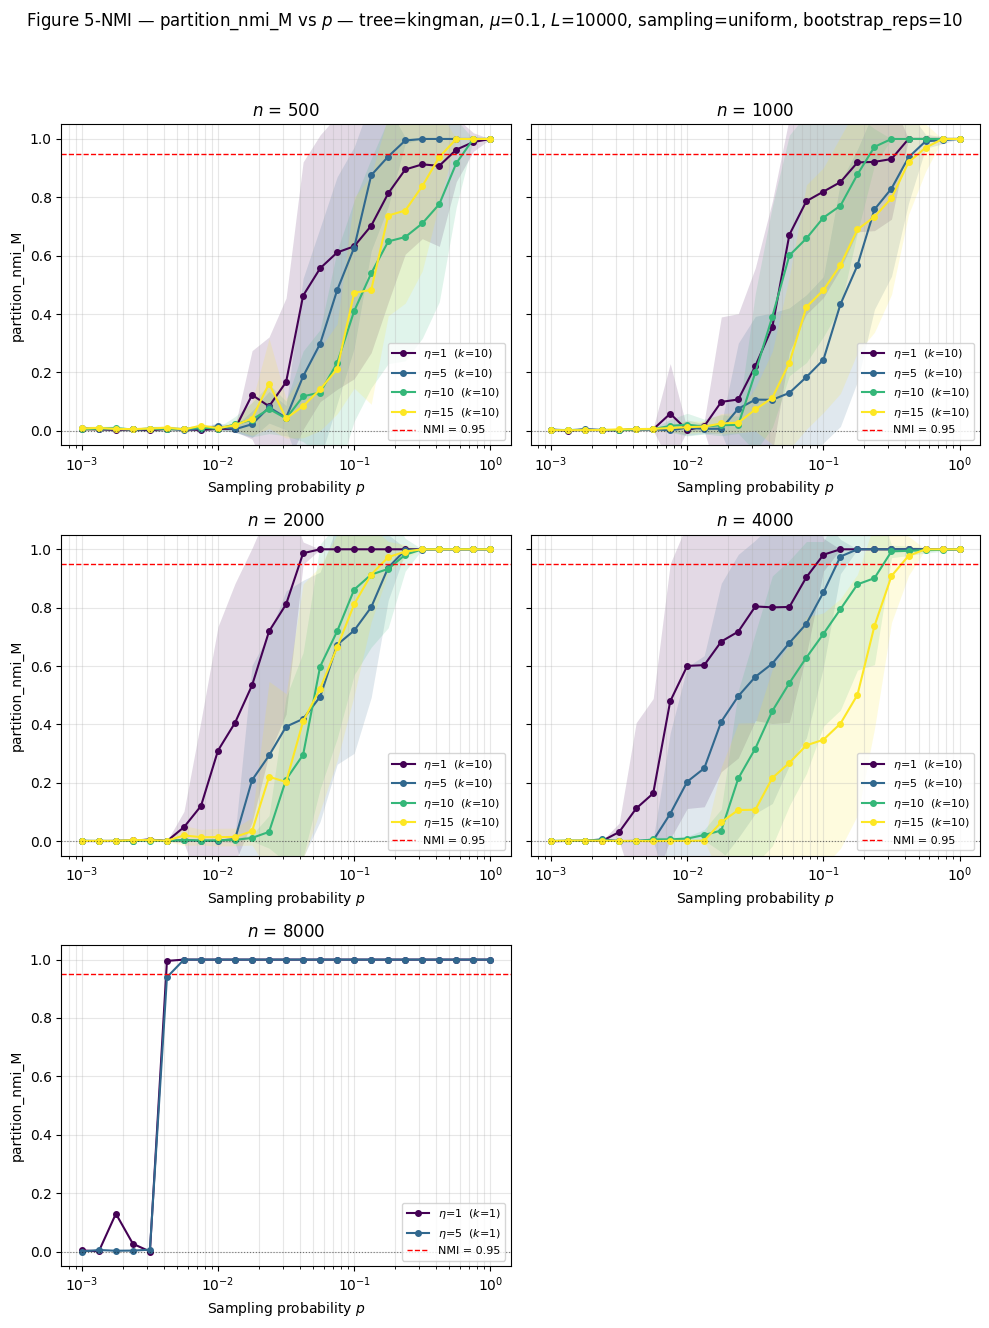

In [ ]:
# Figure 5-NMI — mean partition_nmi_M vs p, one subplot per n, curves by eta.
if not ns:
    print("No matching pool keys found — nothing to plot.")
else:
    cmap = plt.get_cmap("viridis")
    eta_to_color = {
        e: cmap(i / max(1, len(ETA_TARGETS) - 1))
        for i, e in enumerate(ETA_TARGETS)
    }

    n_ns = len(ns)
    ncols = 2
    nrows = (n_ns + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(5 * ncols, 4.5 * nrows),
        sharey=True, squeeze=False,
    )
    axes_flat = axes.flatten()
    fig.suptitle(
        fr"Figure 5-NMI — partition_nmi_M vs $p$ — "
        fr"tree={TREE_MODEL}, $\mu$={MU}, $L$={SEQ_LEN}, sampling=uniform, "
        fr"bootstrap_reps={BOOTSTRAP_REPS}"
    )

    for ax, n in zip(axes_flat, ns):
        for eta in ETA_TARGETS:
            arr = results_nmi.get((n, eta))
            if arr is None or arr.shape[0] == 0:
                continue
            mean = arr.mean(axis=0)
            std = arr.std(axis=0) if arr.shape[0] > 1 else np.zeros_like(mean)
            color = eta_to_color[eta]
            ax.plot(
                P_VALUES, mean, "-o", ms=4, lw=1.5, color=color,
                label=fr"$\eta$={eta}  ($k$={arr.shape[0]})",
            )
            if arr.shape[0] > 1:
                ax.fill_between(P_VALUES, mean - std, mean + std,
                                color=color, alpha=0.15, linewidth=0)

        ax.axhline(0.95, color="red", ls="--", lw=1, label="NMI = 0.95")
        ax.axhline(0.0, color="black", ls=":", lw=0.8, alpha=0.5)
        ax.set_xscale("log")
        ax.set_xlabel(r"Sampling probability $p$")
        ax.set_title(fr"$n$ = {n}")
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, which="both", alpha=0.3)
        ax.legend(loc="lower right", fontsize=8)

    for ax in axes_flat[n_ns:]:
        ax.set_visible(False)

    for row in axes:
        row[0].set_ylabel("partition_nmi_M")
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()

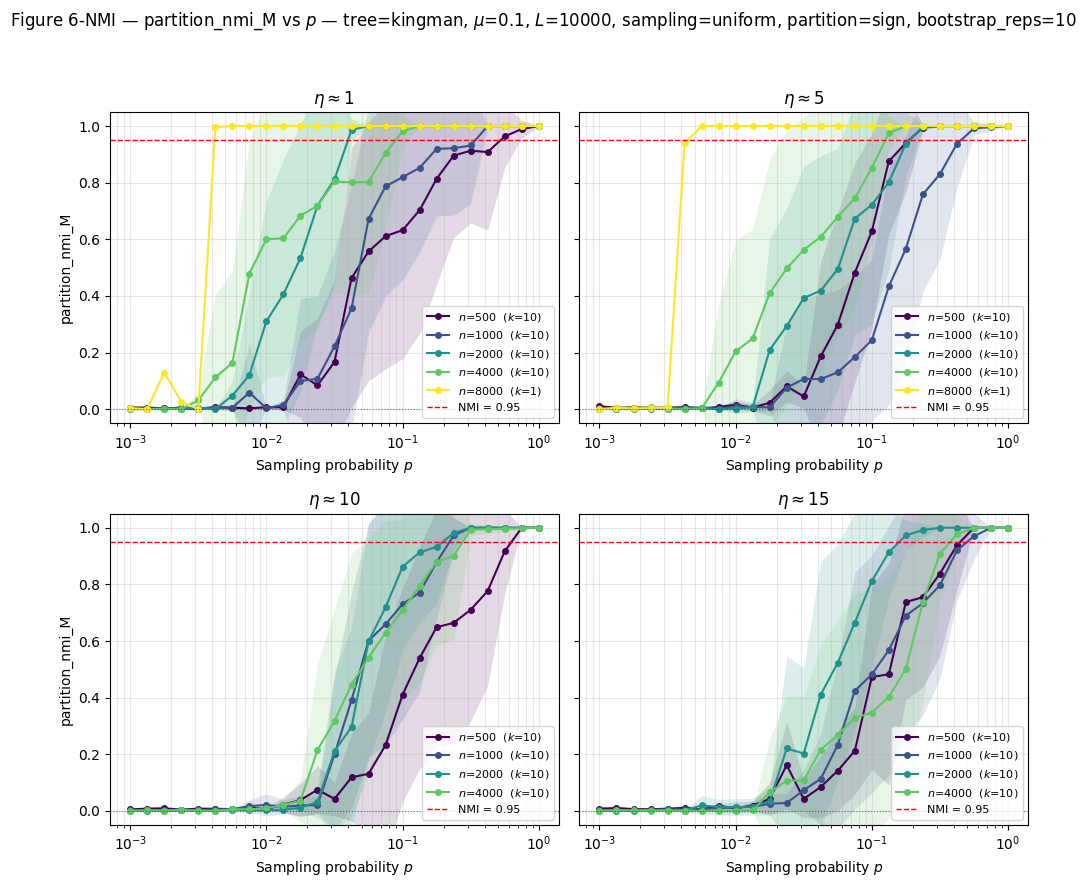

In [ ]:
# Figure 6-NMI — mean partition_nmi_M vs p, one subplot per eta, curves by n.
if not ns:
    print("No matching pool keys found — nothing to plot.")
else:
    cmap = plt.get_cmap("viridis")
    n_to_color = {
        n: cmap(i / max(1, len(ns) - 1))
        for i, n in enumerate(ns)
    }

    n_etas = len(ETA_TARGETS)
    ncols = 2
    nrows = (n_etas + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(5 * ncols, 4.5 * nrows),
        sharey=True, squeeze=False,
    )
    axes_flat = axes.flatten()
    fig.suptitle(
        fr"Figure 6-NMI — partition_nmi_M vs $p$ — "
        fr"tree={TREE_MODEL}, $\mu$={MU}, $L$={SEQ_LEN}, sampling=uniform, "
        fr"partition={PARTITION_METHOD}, bootstrap_reps={BOOTSTRAP_REPS}"
    )

    for ax, eta in zip(axes_flat, ETA_TARGETS):
        for n in ns:
            arr = results_nmi.get((n, eta))
            if arr is None or arr.shape[0] == 0:
                continue
            mean = arr.mean(axis=0)
            std = arr.std(axis=0) if arr.shape[0] > 1 else np.zeros_like(mean)
            color = n_to_color[n]
            ax.plot(
                P_VALUES, mean, "-o", ms=4, lw=1.5, color=color,
                label=fr"$n$={n}  ($k$={arr.shape[0]})",
            )
            if arr.shape[0] > 1:
                ax.fill_between(P_VALUES, mean - std, mean + std,
                                color=color, alpha=0.15, linewidth=0)

        ax.axhline(0.95, color="red", ls="--", lw=1, label="NMI = 0.95")
        ax.axhline(0.0, color="black", ls=":", lw=0.8, alpha=0.5)
        ax.set_xscale("log")
        ax.set_xlabel(r"Sampling probability $p$")
        ax.set_title(fr"$\eta \approx {eta}$")
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, which="both", alpha=0.3)
        ax.legend(loc="lower right", fontsize=8)

    for ax in axes_flat[n_etas:]:
        ax.set_visible(False)

    for row in axes:
        row[0].set_ylabel("partition_nmi_M")
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()

  eta= 1: n=500->p*=0.5623, n=1000->p*=0.4217, n=2000->p*=0.04217, n=4000->p*=0.1, n=8000->p*=0.004217
  eta= 5: n=500->p*=0.2371, n=1000->p*=0.5623, n=2000->p*=0.2371, n=4000->p*=0.1334, n=8000->p*=0.005623
  eta=10: n=500->p*=0.7499, n=1000->p*=0.2371, n=2000->p*=0.2371, n=4000->p*=0.3162, n=8000->p*=0.07499
  eta=15: n=500->p*=0.5623, n=1000->p*=0.5623, n=2000->p*=0.1778, n=4000->p*=0.4217, n=8000->p*=0.05623


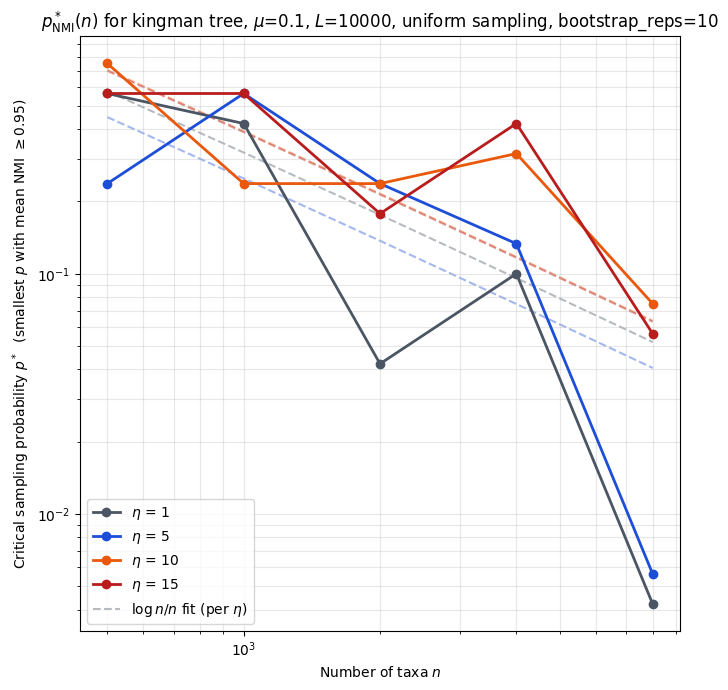

In [34]:
# Figure 7-NMI — critical p* vs n using NMI >= 0.95 as the recovery threshold.
RECOVERY_THRESHOLD_NMI = 0.95  # NMI in [0, 1]

p_arr = np.asarray(P_VALUES, dtype=float)
p_star_nmi_by_eta = {}

for eta in ETA_TARGETS:
    rows = []
    for n in ns:
        arr = results_nmi.get((n, eta))
        if arr is None or arr.shape[0] == 0:
            continue
        mean_curve = arr.mean(axis=0)
        p_star = find_discrete_threshold(p_arr, mean_curve, threshold=RECOVERY_THRESHOLD_NMI)
        if p_star is None or not np.isfinite(p_star):
            continue
        rows.append((n, float(p_star)))
    p_star_nmi_by_eta[eta] = rows
    print(f"  eta={eta:>2}: " + ", ".join(f"n={n}->p*={p:.4g}" for n, p in rows))

fig, ax = plt.subplots(figsize=(7, 7))
for eta in ETA_TARGETS:
    rows = p_star_nmi_by_eta.get(eta, [])
    if not rows:
        continue
    xs = np.array([r[0] for r in rows], dtype=float)
    ys = np.array([r[1] for r in rows], dtype=float)
    ax.plot(
        xs, ys, "-o", ms=6, lw=2,
        color=ETA_COLORS.get(eta, "#000000"),
        label=fr"$\eta$ = {eta}",
    )

# Per-eta log(n)/n reference, least-squares-fit to each eta's own p* points.
n_grid = np.array(sorted(ns), dtype=float)
g_grid = np.log(n_grid) / n_grid
for _i, eta in enumerate(ETA_TARGETS):
    _rows = p_star_nmi_by_eta.get(eta, [])
    if not _rows:
        continue
    _xs = np.array([r[0] for r in _rows], dtype=float)
    _ys = np.array([r[1] for r in _rows], dtype=float)
    _g = np.log(_xs) / _xs
    _C = float(np.dot(_g, _ys) / np.dot(_g, _g))  # fit p* = C * log(n)/n
    ax.plot(n_grid, _C * g_grid, "--", lw=1.5, alpha=0.4, zorder=1,
            color=ETA_COLORS.get(eta, "#000000"),
            label=(r"$\log n/n$ fit (per $\eta$)" if _i == 0 else None))

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Number of taxa $n$")
ax.set_ylabel(r"Critical sampling probability $p^*$  (smallest $p$ with mean NMI $\geq 0.95$)")
ax.set_title(
    fr"$p^*_{{\mathrm{{NMI}}}}(n)$ for kingman tree, $\mu$={MU}, $L$={SEQ_LEN}, uniform sampling, "
    fr"bootstrap_reps={BOOTSTRAP_REPS}"
)
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower left", fontsize=10)
fig.tight_layout()
plt.show()